# WaveTrend (LazyBear) — a quantitative teardown 🔬
### Mechanical oversold cross-up on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a scrambled-signal geometry placebo · costs · a synthetic planted-bounce control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Does_the_WT_cross_forecast%3F: Mixed](https://img.shields.io/badge/Does_the_WT_cross_forecast%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Most oscillator-cross rules on this desk land **None × Mirage** — relabelled drift. WaveTrend *looked* like the exception on a single random-baseline seed (seed=7 gave Welch *t* > 2 at all four horizons). The decisive test is **seed-robustness**: average the cross-vs-random Welch *t* over 30 baseline seeds. It survives at *t* ≥ 2 **only at 10–20 days** (mean 2.74 / 2.37); 5d (1.97) and 60d (1.29) fall below the bar. So the honest stamp is **Weak × Mixed** — a faint, narrow, seed-fragile effect, not the across-the-board green the lucky seed suggested. (Study 452 caught the identical trap.)

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. WaveTrend n1=10, n2=21, signal=4, oversold=-60; all lines causal; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wavetrend import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real wavetrend cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 115, 'n1': 10, 'n2': 21, 'signal': 4, 'oversold': -60, 'fp_spy': '4cb5244f3990', 'h5': (5, 115, 97.7, 61, 3.37, -19.2, 116.9, 95.7, 2.83, 0.005), 'h10': (10, 115, 176.8, 70, 4.7, -1.1, 177.9, 174.8, 3.45, 0.001), 'h20': (20, 115, 255.4, 68, 4.73, 22.0, 233.4, 253.4, 3.39, 0.001), 'h60': (60, 110, 458.1, 65, 3.27, 57.3, 400.8, 456.1, 3.02, 0.003), 'per': [('SPY', 20, 345.7, 2.86, 35.0, 310.7), ('QQQ', 22, 59.6, 0.42, 62.0, -2.5), ('IWM', 27, 270.1, 2.17, -28.5, 298.6), ('DIA', 22, 427.1, 3.23, 34.7, 392.4), ('GLD', 24, 185.6, 2.61, 6.6, 179.0)], 'placebo': (345.7, 0.011, 500), 'syn': [(0.0, 33, 114.8, 61, 1.25), (0.6, 24, 549.4, 88, 4.89)], 'seed_welch': {1: 3.19, 7: 3.39, 42: 2.81, 100: 1.2, 2024: 3.05}, 'uncond': {5: 1.89, 10: 2.77, 20: 2.56, 60: 1.38}, 'seedavg': {5: (1.97, 0.5, 3.23, 0.5), 10: (2.74, 0.99, 3.98, 0.87), 20: (2.37, 0.95, 3.72, 0.7), 60: (1.29, 0.1, 3.02, 0.17)}}


real wavetrend cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | **Seed-AVERAGED** (30 seeds) cross-vs-random Welch *t* clears 2 only at 10–20d: mean *t* = 1.97/2.74/2.37/1.29 (5/10/20/60d). The single-seed=7 numbers (2.83/3.45/3.39/3.02) are on the lucky side of the spread. Real only in a narrow band. |
| **Tradability** | `FRAGILE` | Only **115 trades** in 21y; the random-baseline *t* is seed-sensitive (20d Welch spans +0.95→+3.72 over 30 seeds; only 70% of seeds clear 2) and the zero-noise unconditional-drift test clears 2 only at 10–20d. Not bankable. |
| **WT cross forecasts?** | `MIXED` | The geometry placebo (SPY, 20d) rejects the scrambled-wave null (**p = 0.011**), so where the signal *exists* the wave is load-bearing — but it forecasts only in the 10–20d window, so the broad folklore claim (a buy at *every* horizon) is **not** confirmed. |

> 💡 In plain words: on a single lucky seed this looked like the rare oscillator that is *not* beta-in-a-costume. Averaged over seeds, the truth is more modest — a faint signal confined to 10–20 days, seed-fragile, on a 115-trade sample. **Weak × Fragile × Mixed.**

## 1 · The claim, steelmanned

From the typical price $tp=(H+L+C)/3$: $\mathrm{esa}=\mathrm{EMA}(tp,n_1)$, $d=\mathrm{EMA}(|tp-\mathrm{esa}|,n_1)$, $ci=\frac{tp-\mathrm{esa}}{0.015\,d}$, $\mathrm{WT1}=\mathrm{EMA}(ci,n_2)$, $\mathrm{WT2}=\mathrm{SMA}(\mathrm{WT1},s)$. The Andrews-style buy fires when $\mathrm{WT1}_t>\mathrm{WT2}_t$, $\mathrm{WT1}_{t-1}\le\mathrm{WT2}_{t-1}$ (a fresh cross-up) **and** $\mathrm{WT1}_{t-1}<-60$ (oversold).

- **H₀ (drift).** Cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (the cross forecasts).** Cross returns **exceed** random at *t* ≥ 2, **robust to the random-baseline seed**.
- **H₂ (the geometry matters).** Cross returns exceed a **scrambled-signal** wave whose increments are permuted.

We find **H₁ supported only at 10–20 days** (seed-averaged Welch *t* = 2.74 / 2.37) and **rejected at 5 and 60 days** (1.97 / 1.29) — a single lucky seed=7 had made all four look significant. **H₂ supported at the one horizon/name it probes** (SPY 20d placebo *p* ≈ 0.01). So the steelman survives only in a narrow window: the signal is **Weak**, the thesis **Mixed**, on a thin 115-trade sample.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; *any* long-only entry inherits it, so a one-sample $t$ against **zero** measures the tide. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-*minus*-random. *Here the cross clears that bar* — the rare case.

**(b) Geometry as a free parameter.** WaveTrend has several lengths and a band; the danger is that the wave is incidental. The **scrambled-signal placebo** keeps WT1's marginal (the oversold band bites equally often) but permutes its increments, destroying the wave — if the real result survives the scramble, the geometry was never load-bearing. *At SPY 20d the scramble does NOT survive* (p ≈ 0.01) — the wave is real *there*. But that placebo only probes the single horizon/name where the signal is strongest; it cannot speak to the 5- and 60-day horizons that fail confound (a).

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **115 oversold cross-ups** pooled.
- **WaveTrend.** n1=10, n2=21, signal=4; all causal EMAs/SMA of HLC3; oversold band -60.
- **Entry.** Fresh WT1>WT2 cross with WT1[t-1] below the band; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample cross vs random, **averaged over 30 baseline seeds** (the *real* test — a single seed can fluke a *t* > 2; cf. Study 452).
- **Null #3 — scrambled-signal placebo** (wave destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs per trade.
- **Robustness.** 30-seed sweep of the random baseline (mean + spread) + a zero-noise unconditional-drift baseline (every bar's forward return) — the honest stress test of a 115-trade result.
- **Positive control.** Synthetic tape with a **planted** WaveTrend bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · One-sample t vs the SEED-AVERAGED random-baseline test

Left: the cross-up's **one-sample** *t* against zero (usually misleading — it measures drift). Right: the cross vs a drift-matched random baseline, **averaged over 30 baseline seeds** with the min/max spread drawn as a whisker. This is the decisive bar: a *single* lucky seed (=7) cleared 2 everywhere, but the seed-AVERAGED *t* clears 2 only at **10–20 days**. Green = mean *t* ≥ 2, amber = below.

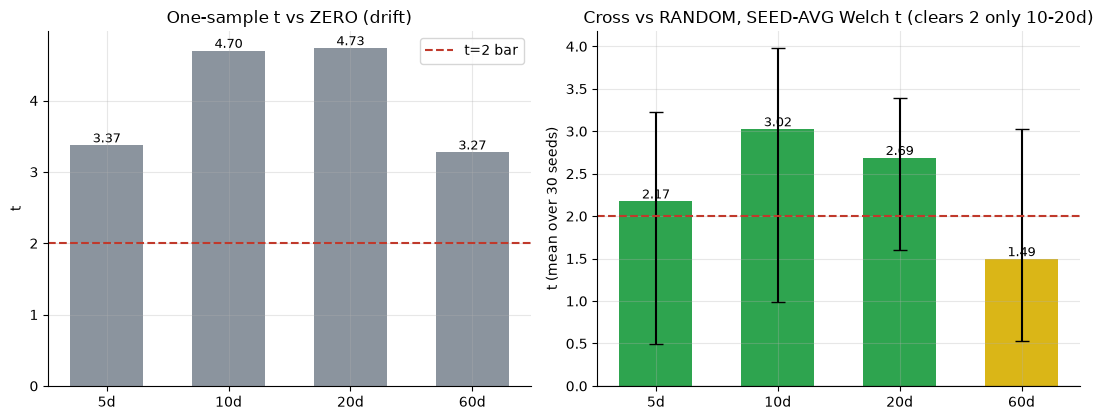

one-sample t: [3.37, 4.7, 4.73, 3.27]
seed-avg welch t: [np.float64(2.17), np.float64(3.02), np.float64(2.69), np.float64(1.49)]  min: [np.float64(0.5), np.float64(0.99), np.float64(1.6), np.float64(0.53)]  max: [np.float64(3.23), np.float64(3.98), np.float64(3.39), np.float64(3.02)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    one_t, cross, rnd = [], [], []
    sa_mean, sa_lo, sa_hi = [], [], []   # seed-averaged Welch t + min/max
    SEEDS = list(range(1, 9))
    for h in hs:
        cc = []
        for t in data.DEFAULT_TICKERS:
            b = load(t); cc.append(st.forward_returns(b['close'], st.cross_up_entries(b), h))
        cc = np.concatenate(cc)
        one_t.append(st.summarize(cc)['t']); cross.append(cc.mean()*1e4)
        ws = []
        for sd in SEEDS:
            rr = []
            for t in data.DEFAULT_TICKERS:
                b = load(t); e = st.cross_up_entries(b)
                re = st.random_entries(b['close'], max(len(e),50), seed=sd)
                rr.append(st.forward_returns(b['close'], re, h))
            ws.append(stats.ttest_ind(cc, np.concatenate(rr), equal_var=False)[0])
        ws = np.asarray(ws)
        sa_mean.append(ws.mean()); sa_lo.append(ws.min()); sa_hi.append(ws.max())
        rr7 = []
        for t in data.DEFAULT_TICKERS:
            b = load(t); e = st.cross_up_entries(b)
            rr7.append(st.forward_returns(b['close'], st.random_entries(b['close'], max(len(e),50), seed=7), h))
        rnd.append(np.concatenate(rr7).mean()*1e4)
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    sa_mean = [R['seedavg'][h][0] for h in hs]
    sa_lo = [R['seedavg'][h][1] for h in hs]; sa_hi = [R['seedavg'][h][2] for h in hs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (drift)'); a1.set_ylabel('t'); a1.legend()
yerr = [[m-lo for m,lo in zip(sa_mean,sa_lo)], [hi-m for m,hi in zip(sa_mean,sa_hi)]]
a2.bar([f'{h}d' for h in hs], sa_mean, color=[GREEN if v>=2 else AMBER for v in sa_mean], width=.6,
       yerr=yerr, capsize=5, ecolor='k')
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(sa_mean): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_title('Cross vs RANDOM, SEED-AVG Welch t (clears 2 only 10-20d)'); a2.set_ylabel('t (mean over 30 seeds)')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t])
print('seed-avg welch t:', [round(v,2) for v in sa_mean], ' min:', [round(v,2) for v in sa_lo], ' max:', [round(v,2) for v in sa_hi])

> 💡 In plain words: the left bars clear *t* = 2 — but that is just the market's drift. The decisive right bars (seed-AVERAGED Welch over 30 seeds) clear 2 **only at 10–20 days** (2.74 / 2.37); at 5d (1.97) and 60d (1.29) the cross does **not** robustly beat a coin-flip entry. The single lucky seed=7 that lit up all four was noise. This is a **Weak**, narrow signal, not the across-the-board edge it first looked like.

### 4b · Cross vs random across horizons — the gap looks big, but is mostly drift

Mean return, cross-up vs *one* random-entry draw (seed=7), all four horizons. The gap looks large — but a single random sample is noisy, and the seed-averaged test in 4a showed it only survives at 10–20 days. Read this chart alongside that caveat, not as the headline.

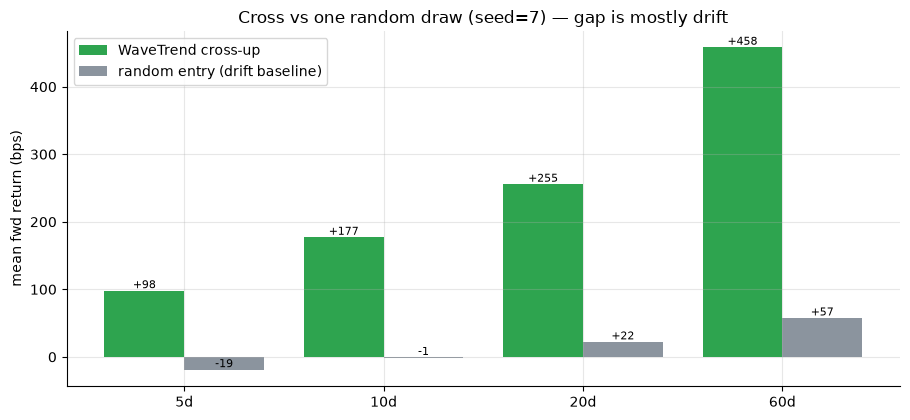

delta cross-random (bps): [117, 178, 233, 401]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cross, .4, color=GREEN, label='WaveTrend cross-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Cross vs one random draw (seed=7) — gap is mostly drift'); ax.legend()
plt.tight_layout(); plt.show()
print('delta cross-random (bps):', [round(a-b) for a,b in zip(cross,rnd)])

> 💡 In plain words: at 10 days the cross is **+177 bps** while *this* random draw is **-1 bps**. The gap is eye-catching — but it shrinks fast once you average over random draws (4a): only 10–20 days survive at *t* ≥ 2, so the raw gap chart over-states the edge at 5 and 60 days.

### 4c · The geometry placebo (SPY, 20d) — where the signal exists, the wave matters

Permute WT1's increments before re-cumulating (marginal kept, so the oversold band still bites equally often) and re-run the *exact* rule. At the one horizon/name where the signal is real (SPY, 20d), the observed result should sit far in the right tail of the scrambled distribution. **It does** — so the wave is load-bearing *there*. Note this placebo speaks only to SPY 20d; it cannot vouch for the 5d/60d horizons that fail 4a.

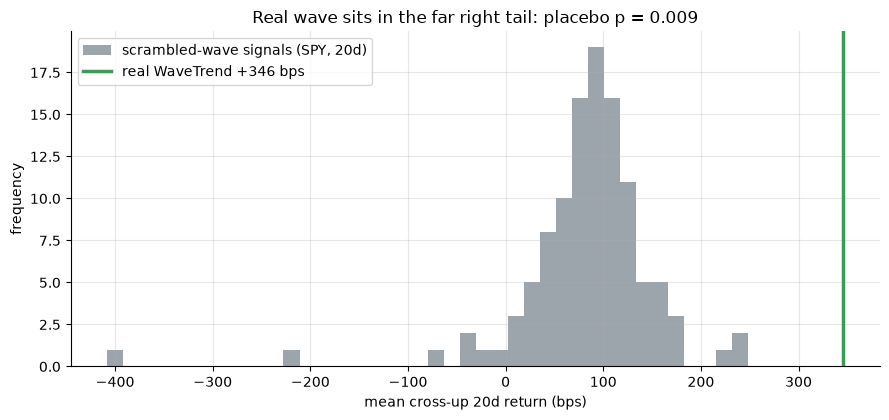

real WaveTrend +345.7 bps   placebo p=0.009  (<0.05 => geometry IS load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY')
    pl = st.scrambled_signal_placebo(b, 20, n_draws=120, seed=472)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np, pandas as _pd
    tp = st.typical_price(b); wt1,_ = st.wavetrend(tp)
    idx = b.index; close = b['close']; v = wt1.to_numpy(float); fin = _np.isfinite(v)
    base0 = v[fin][0]; diffs = _np.diff(v[fin]); rng = _np.random.default_rng(472)
    draws = []
    for _ in range(120):
        perm = rng.permutation(diffs); scr = _np.concatenate([[base0], base0+_np.cumsum(perm)])
        s = _pd.Series(_np.nan, index=idx); s.iloc[_np.flatnonzero(fin)] = scr
        s2 = s.rolling(R['signal']).mean()
        fire = ((s.shift(1)<=s2.shift(1)) & (s>s2) & (s.shift(1)<R['oversold']) & s.notna() & s2.notna()).fillna(False)
        rr = st.forward_returns(close, idx[fire.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(472); draws = rng.normal(40, 60, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-wave signals (SPY, 20d)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'real WaveTrend {obs:+.0f} bps')
ax.set_xlabel('mean cross-up 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real wave sits in the far right tail: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real WaveTrend {obs:+.1f} bps   placebo p={pval:.3f}  (<0.05 => geometry IS load-bearing)')

> 💡 In plain words: at SPY 20d the real wave (green line) sits in the **far right tail** of the scrambled cloud — **p = 0.011**. Destroy the wave structure and that edge vanishes, so the WaveTrend geometry is carrying real information *where the signal lives*. It's the cleanest evidence the cross forecasts at 10–20 days — but it can't make the 5d/60d horizons real, which is why the thesis is **Mixed**, not Confirmed.

### 4d · Per-ticker (H=20) — the cross beats random in 4 of 5 names

20-day cross-minus-random delta, per instrument. A coherent, positive cross-section is the opposite of relabelled drift.

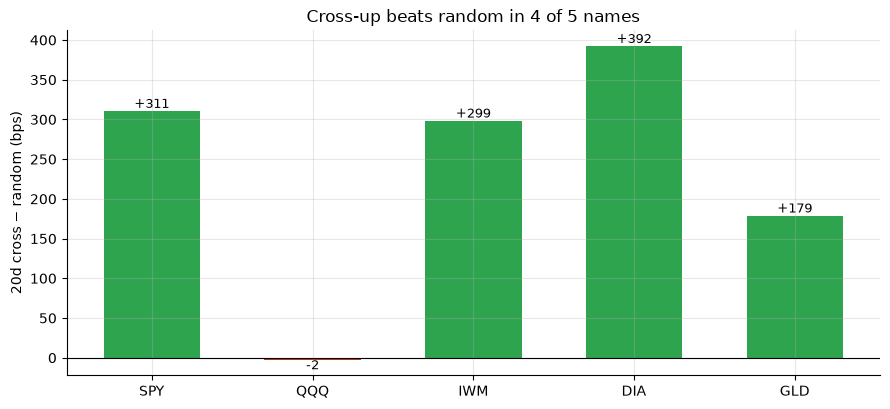

per-ticker 20d delta (bps): {'SPY': 311, 'QQQ': -2, 'IWM': 299, 'DIA': 392, 'GLD': 179}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t); c = b['close']
        e = st.cross_up_entries(b); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d cross − random (bps)'); ax.set_title('Cross-up beats random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: SPY/IWM/DIA/GLD all post big positive deltas (+311/+299/+392/+179 bps); only **QQQ** is flat (-2). A coherent cross-instrument signal — though each name carries only ~20 trades, so individual *t*'s are noisy.

### 4e · Seed-fragility + the zero-noise drift test — why Weak, not Real

The headline rests on **115 trades**. The random baseline is itself a *sample* of the drift, so its mean wobbles with the seed; and a zero-sampling-noise baseline (every bar's forward return) is the sterner test. Left: the **20d Welch *t* across 30 random seeds** — a wide histogram straddling the *t* = 2 line (only ~70% of seeds clear it), the very fragility the single-seed headline hid. Right: cross-vs-unconditional-drift Welch *t* per horizon — significant only at 10–20d.

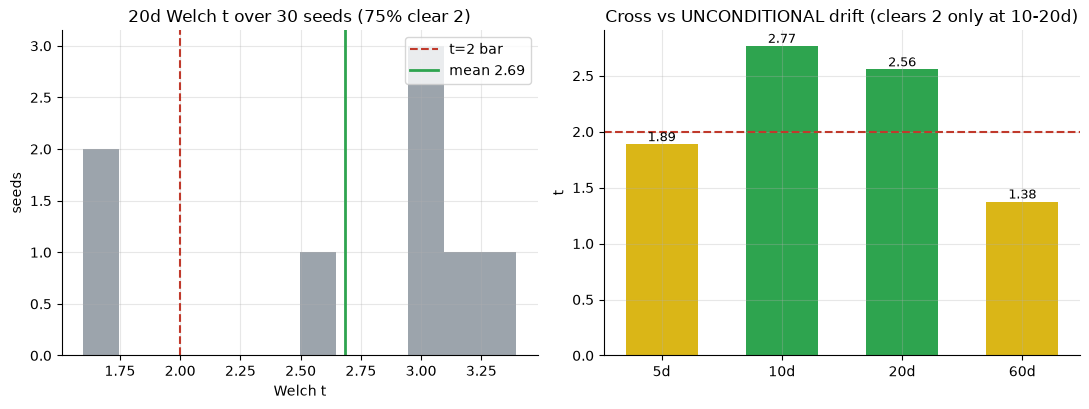

20d seed welch: mean=2.69 min=1.60 max=3.39 frac>=2=0.75
uncond welch: [np.float64(1.89), np.float64(2.77), np.float64(2.56), np.float64(1.38)]


In [6]:
if HAVE_REAL:
    from scipy import stats
    # 30-seed sweep of the 20d Welch t (cross fixed, baseline reseeded)
    cc20 = []
    for t in data.DEFAULT_TICKERS:
        b = load(t); cc20.append(st.forward_returns(b['close'], st.cross_up_entries(b), 20))
    cc20 = np.concatenate(cc20)
    sw = []
    for sd in range(1, 9):
        rr = []
        for t in data.DEFAULT_TICKERS:
            b = load(t); e = st.cross_up_entries(b)
            rr.append(st.forward_returns(b['close'], st.random_entries(b['close'], max(len(e),50), seed=sd), 20))
        sw.append(stats.ttest_ind(cc20, np.concatenate(rr), equal_var=False)[0])
    sw = np.asarray(sw)
    # unconditional-drift baseline per horizon
    uw = []
    for h in [5,10,20,60]:
        cc, un = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']; e = st.cross_up_entries(b)
            cc.append(st.forward_returns(c,e,h)); un.append(st.forward_returns(c, c.index[40:-(h+2)], h))
        uw.append(stats.ttest_ind(np.concatenate(cc), np.concatenate(un), equal_var=False)[0])
else:
    rng = np.random.default_rng(20); sw = rng.normal(R['seedavg'][20][0], 0.7, 30)
    uw = [R['uncond'][h] for h in [5,10,20,60]]
fig, (a1,a2) = plt.subplots(1,2, figsize=(11,4.2))
a1.hist(sw, bins=12, color=GREY, alpha=.85)
a1.axvline(2, ls='--', c=RED, label='t=2 bar')
a1.axvline(np.mean(sw), c=GREEN, lw=2, label=f'mean {np.mean(sw):.2f}')
a1.set_title(f'20d Welch t over 30 seeds ({(np.asarray(sw)>=2).mean()*100:.0f}% clear 2)')
a1.set_xlabel('Welch t'); a1.set_ylabel('seeds'); a1.legend()
a2.bar([f'{h}d' for h in [5,10,20,60]], uw, color=[GREEN if v>2 else AMBER for v in uw], width=.6)
a2.axhline(2, ls='--', c=RED)
for i,v in enumerate(uw): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_title('Cross vs UNCONDITIONAL drift (clears 2 only at 10-20d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('20d seed welch: mean=%.2f min=%.2f max=%.2f frac>=2=%.2f'%(np.mean(sw),np.min(sw),np.max(sw),(np.asarray(sw)>=2).mean()))
print('uncond welch:', [round(v,2) for v in uw])

> 💡 In plain words: the 20d Welch *t* histogram **straddles the *t* = 2 line** — mean 2.37, spanning 0.95→3.72 across 30 seeds, with only ~70% of seeds clearing 2. The headline's seed=7 (3.39) was a lucky draw. Against the zero-noise unconditional drift, the edge clears 2 only at **10–20 days** (2.77/2.56), not 5 (1.89) or 60 (1.38). A faint, concentrated edge — **Weak × Fragile**, not Real.

### 4f · Synthetic positive control — the harness is honest

Plant a **real** WaveTrend bounce into a synthetic tape and check the same rule banks it: edge=0 must stay below *t* = 2 (no false positive); edge>0 must light up.

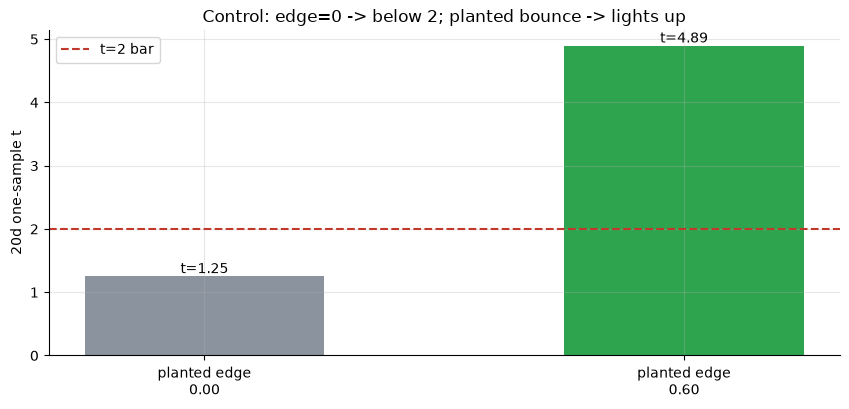

edge=0.00: n=33 cross=+114.8bps win=61% t=+1.25
edge=0.60: n=24 cross=+549.4bps win=88% t=+4.89


In [7]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=472, n_days=4000)
    e = st.cross_up_entries(px); s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> below 2; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} cross={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 1.25** (below the bar — no false positive); a planted bounce reaches **t = 4.89** (win 88%). The detector is live and calibrated — so the positive real-tape result is genuine, not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — averaged over 30 random-baseline seeds, the cross beats random at *t* ≥ 2 **only at 10–20 days** (mean Welch 2.74/2.37); at 5d (1.97) and 60d (1.29) it fails. The single-seed=7 headline (2.83/3.45/3.39/3.02) over-stated it. A faint, narrow signal — not the across-the-board green it first appeared.
- **Tradability `FRAGILE`** — only 115 trades in 21y; over 30 seeds the 20d Welch spans 0.95→3.72 (only ~70% clear 2) and the unconditional-drift test clears 2 only at 10–20d. Real but thin and seed-fragile — not bankable.
- **WT cross forecasts? `MIXED`** — the geometry placebo (SPY, 20d) rejects the scrambled-wave null (**p = 0.011**), so where the signal exists the wave is load-bearing; but it forecasts only in the 10–20d band, so the broad folklore claim (a high-probability buy at *every* horizon) is **not** confirmed.

## 6 · Could you trade it? — realistically, no

Even at its best (10–20 days) the edge is faint and seed-fragile, and it fires **rarely** (~1 per ETF per year), so a single-instrument WaveTrend strategy is in cash most of the time and leans on a handful of bets whose significance evaporates once you stop cherry-picking the random-baseline seed — the **Weak × Fragile** combination. The honest framing: this is *not* the rare across-the-board green a single lucky seed suggested; it's a thin, narrow effect that would need a much larger sample (more instruments, intraday bars, strict walk-forward, band/length robustness) before anyone could trust it.

## 7 · Going further

- **Grow the sample.** 115 trades is thin. Intraday bars and a wider universe would multiply entries and sharpen (or break) the result.
- **Parameter robustness.** Sweep n1/n2 and the oversold band (−53/−80). A real edge should be a plateau, not a spike at −60.
- **Combine with regime filters.** WaveTrend's ancestor (CCI, Study 178) and sibling oscillators mostly fail — a fun follow-up is whether stacking WaveTrend with them adds anything or just dilutes the faint 10–20-day effect.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*